In [2]:
# https://soccermatics.readthedocs.io/en/latest/gallery/lesson9/plot_ClusteringPlayers.html

In [3]:
import scipy
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

# Para clustering
from sklearn.datasets import make_blobs
from sklearn.datasets import make_circles
from sklearn.preprocessing import MinMaxScaler 
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

# Para componentes principales
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
#open data
data = pd.read_csv("../Datos/Football/FBRef2020-21-clean.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Columns: 128 entries, Player to ProgPassReceived/90
dtypes: float64(115), int64(3), object(10)
memory usage: 2.8+ MB


In [6]:
data.columns

Index(['Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Starts', 'Min',
       ...
       'PrgDistCarry/90', 'ProgCarry/90', 'CarryIntoThird/90',
       'CarryIntoBox/90', 'Miscontrol/90', 'Dispossessed/90', 'PassTarget/90',
       'PassesReceived/90', 'PassRec%', 'ProgPassReceived/90'],
      dtype='object', length=128)

In [5]:
data.describe()

,Age,Born,MP,Starts,Min,90s,Ast/90,npG/90,npG+A/90,xA/90,...,PrgDistCarry/90,ProgCarry/90,CarryIntoThird/90,CarryIntoBox/90,Miscontrol/90,Dispossessed/90,PassTarget/90,PassesReceived/90,PassRec%,ProgPassReceived/90
count,2822.000000,2822.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2823.000000,2820.000000,...,2820.000000,2820.000000,2820.000000,2820.000000,2820.000000,2820.000000,2820.000000,2820.000000,2805.000000,2820.000000
mean,25.248760,1994.407512,19.273822,14.230252,1277.629118,14.195997,0.081034,0.093719,0.174754,0.078897,...,94.988230,3.828039,1.167142,0.343014,1.333163,1.203961,43.542755,35.862862,83.210802,3.465833
std,4.611737,4.620108,11.693210,11.485120,988.140192,10.979574,0.231847,0.163769,0.300727,0.147945,...,60.363708,3.010566,1.299178,0.596948,1.679832,1.458072,16.390975,15.312661,16.296027,3.771762
min,14.000000,1977.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,1991.000000,8.000000,3.000000,333.000000,3.700000,0.000000,0.000000,0.000000,0.000000,...,51.900000,1.760000,0.260000,0.000000,0.240000,0.200000,35.500000,25.875000,74.700000,0.330000
50%,25.000000,1995.000000,21.000000,13.000000,1181.000000,13.100000,0.000000,0.000000,0.080000,0.050000,...,90.700000,3.460000,0.980000,0.100000,0.910000,0.910000,44.000000,34.800000,88.700000,2.220000
75%,29.000000,1998.000000,30.000000,24.000000,2083.500000,23.150000,0.110000,0.130000,0.260000,0.110000,...,126.500000,5.302500,1.690000,0.480000,1.990000,1.750000,52.500000,44.100000,96.000000,5.782500
max,42.000000,2005.000000,38.000000,38.000000,3420.000000,38.000000,8.180000,2.090000,8.180000,5.690000,...,900.000000,40.000000,20.000000,10.000000,30.000000,30.000000,120.000000,120.000000,100.000000,50.000000


In [136]:
# Nos quedamos solo con los jugadores que jugaron más de 500 minutos
data = data.loc[data["Min"] > 500]
data = data.reset_index(drop = True)

In [118]:
data

,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,Min,...,PrgDistCarry/90,ProgCarry/90,CarryIntoThird/90,CarryIntoBox/90,Miscontrol/90,Dispossessed/90,PassTarget/90,PassesReceived/90,PassRec%,ProgPassReceived/90
0,Patrick van Aanholt,nl NED,DF,Crystal Palace,eng Premier League,29.0,1990.0,22,20,1777,...,96.8,5.79,1.52,0.46,0.66,0.81,42.3,39.3,92.8,2.34
1,Yunis Abdelhamid,ma MAR,DF,Reims,fr Ligue 1,32.0,1987.0,33,33,2889,...,130.5,1.81,0.25,0.03,0.25,0.47,43.8,42.5,97.0,0.22
2,Pape Abou Cisse,sn SEN,DF,Saint-Étienne,fr Ligue 1,24.0,1995.0,14,14,1260,...,117.9,1.14,0.07,0.00,0.14,0.07,33.7,32.9,97.7,0.00
3,David Abraham,ar ARG,DF,Eint Frankfurt,de Bundesliga,34.0,1986.0,14,14,1222,...,92.7,3.24,0.66,0.00,0.22,0.00,34.8,33.4,96.0,0.59
4,Francesco Acerbi,it ITA,DF,Lazio,it Serie A,32.0,1988.0,32,32,2813,...,166.3,3.71,1.02,0.03,0.45,0.26,50.9,49.5,97.3,0.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1954,Reinhold Yabo,de GER,"MF,FW",Arminia,de Bundesliga,28.0,1992.0,13,8,647,...,76.3,3.47,1.39,0.42,0.97,0.97,31.1,21.0,67.4,2.78
1955,Amin Younes,de GER,"MF,FW",Eint Frankfurt,de Bundesliga,26.0,1993.0,26,16,1391,...,138.4,8.71,2.00,1.03,2.19,2.58,58.1,44.3,76.2,8.26
1956,Mattia Zaccagni,it ITA,"MF,FW",Hellas Verona,it Serie A,25.0,1995.0,36,33,2609,...,141.8,7.45,2.52,1.10,2.31,2.86,49.2,35.5,72.1,8.21
1957,Arber Zeneli,xk KVX,"MF,FW",Reims,fr Ligue 1,25.0,1995.0,28,14,1289,...,102.0,5.24,1.40,1.12,2.94,2.45,40.3,28.0,69.3,6.15


In [10]:
# Miramos si hay datos faltantes
data.isna().sum()

Player                  0
Nation                  0
Pos                     0
Squad                   0
Comp                    0
                       ..
Dispossessed/90         3
PassTarget/90           3
PassesReceived/90       3
PassRec%               18
ProgPassReceived/90     3
Length: 128, dtype: int64

In [12]:
# Como son muchas columnas, vemos las cantidades de datos faltantes
data.isna().sum().value_counts()

3      89
0      22
1       2
540     2
543     2
4       2
906     1
17      1
45      1
62      1
130     1
348     1
103     1
455     1
18      1
Name: count, dtype: int64

In [13]:
# Eliminamos primero las columnas con más de 100 datos faltantes
nan_cols = data.isna().sum() > 100  # Vector booleano
keep = nan_cols.index[~(nan_cols)] # Lista con los nombres de las columnas para dejar
dataNaN = data[keep] # Seleccionamos solo las columnas en keep

# Eliminamos las columnas de porcentajes porque tienen muchos div by 0
dataNaN = dataNaN.drop(["%TchsDefPen", "%TchsDefThrd", "%TchsMidThrd", "%TchsAttThrd","%TchsAttPen"], axis = 1)

In [19]:
X = dataNaN.iloc[:, 11:].dropna()
X.dtypes

Ast/90                 float64
npG/90                 float64
npG+A/90               float64
xA/90                  float64
npxG/90                float64
                        ...   
Dispossessed/90        float64
PassTarget/90          float64
PassesReceived/90      float64
PassRec%               float64
ProgPassReceived/90    float64
Length: 103, dtype: object

In [21]:
data.Pos.value_counts()

Pos
DF       906
MF       594
FW       386
FW,MF    298
MF,FW    228
GK       207
DF,MF     79
MF,DF     69
DF,FW     34
FW,DF     21
GK,MF      1
Name: count, dtype: int64

In [23]:
# Definimos una nueva columna con la primera posicion
data["Pos1"] = data["Pos"].str.strip().str[0:2]

In [24]:
# Componentes principales
pca = PCA(n_components=2)

X_star_p = StandardScaler().set_output(transform="pandas").fit_transform(X)

principalComponents = pca.fit_transform(X_star_p)
pComp = pd.DataFrame(principalComponents).set_index(X_star_p.index)

pComp.columns = ["Z1", "Z2"]
pComp

# Le pegamos las columnas de nombre, y posicion
pCompPos = pd.concat([pComp, data[["Player", "Pos", "Pos1"]]], axis = 1).dropna()
pCompPos

,Z1,Z2,Player,Pos,Pos1
0,2.839413,-0.725329,Patrick van Aanholt,DF,DF
1,2.722513,-4.525030,Yunis Abdelhamid,DF,DF
2,0.842101,-5.285580,Pape Abou Cisse,DF,DF
3,1.303831,-3.611667,David Abraham,DF,DF
4,5.303883,-3.851450,Francesco Acerbi,DF,DF
...,...,...,...,...,...
2818,-4.754503,-0.467844,Reinhold Yabo,"MF,FW",MF
2819,1.042545,6.777857,Amin Younes,"MF,FW",MF
2820,-2.064892,4.789323,Mattia Zaccagni,"MF,FW",MF
2821,-3.533995,3.757903,Arber Zeneli,"MF,FW",MF


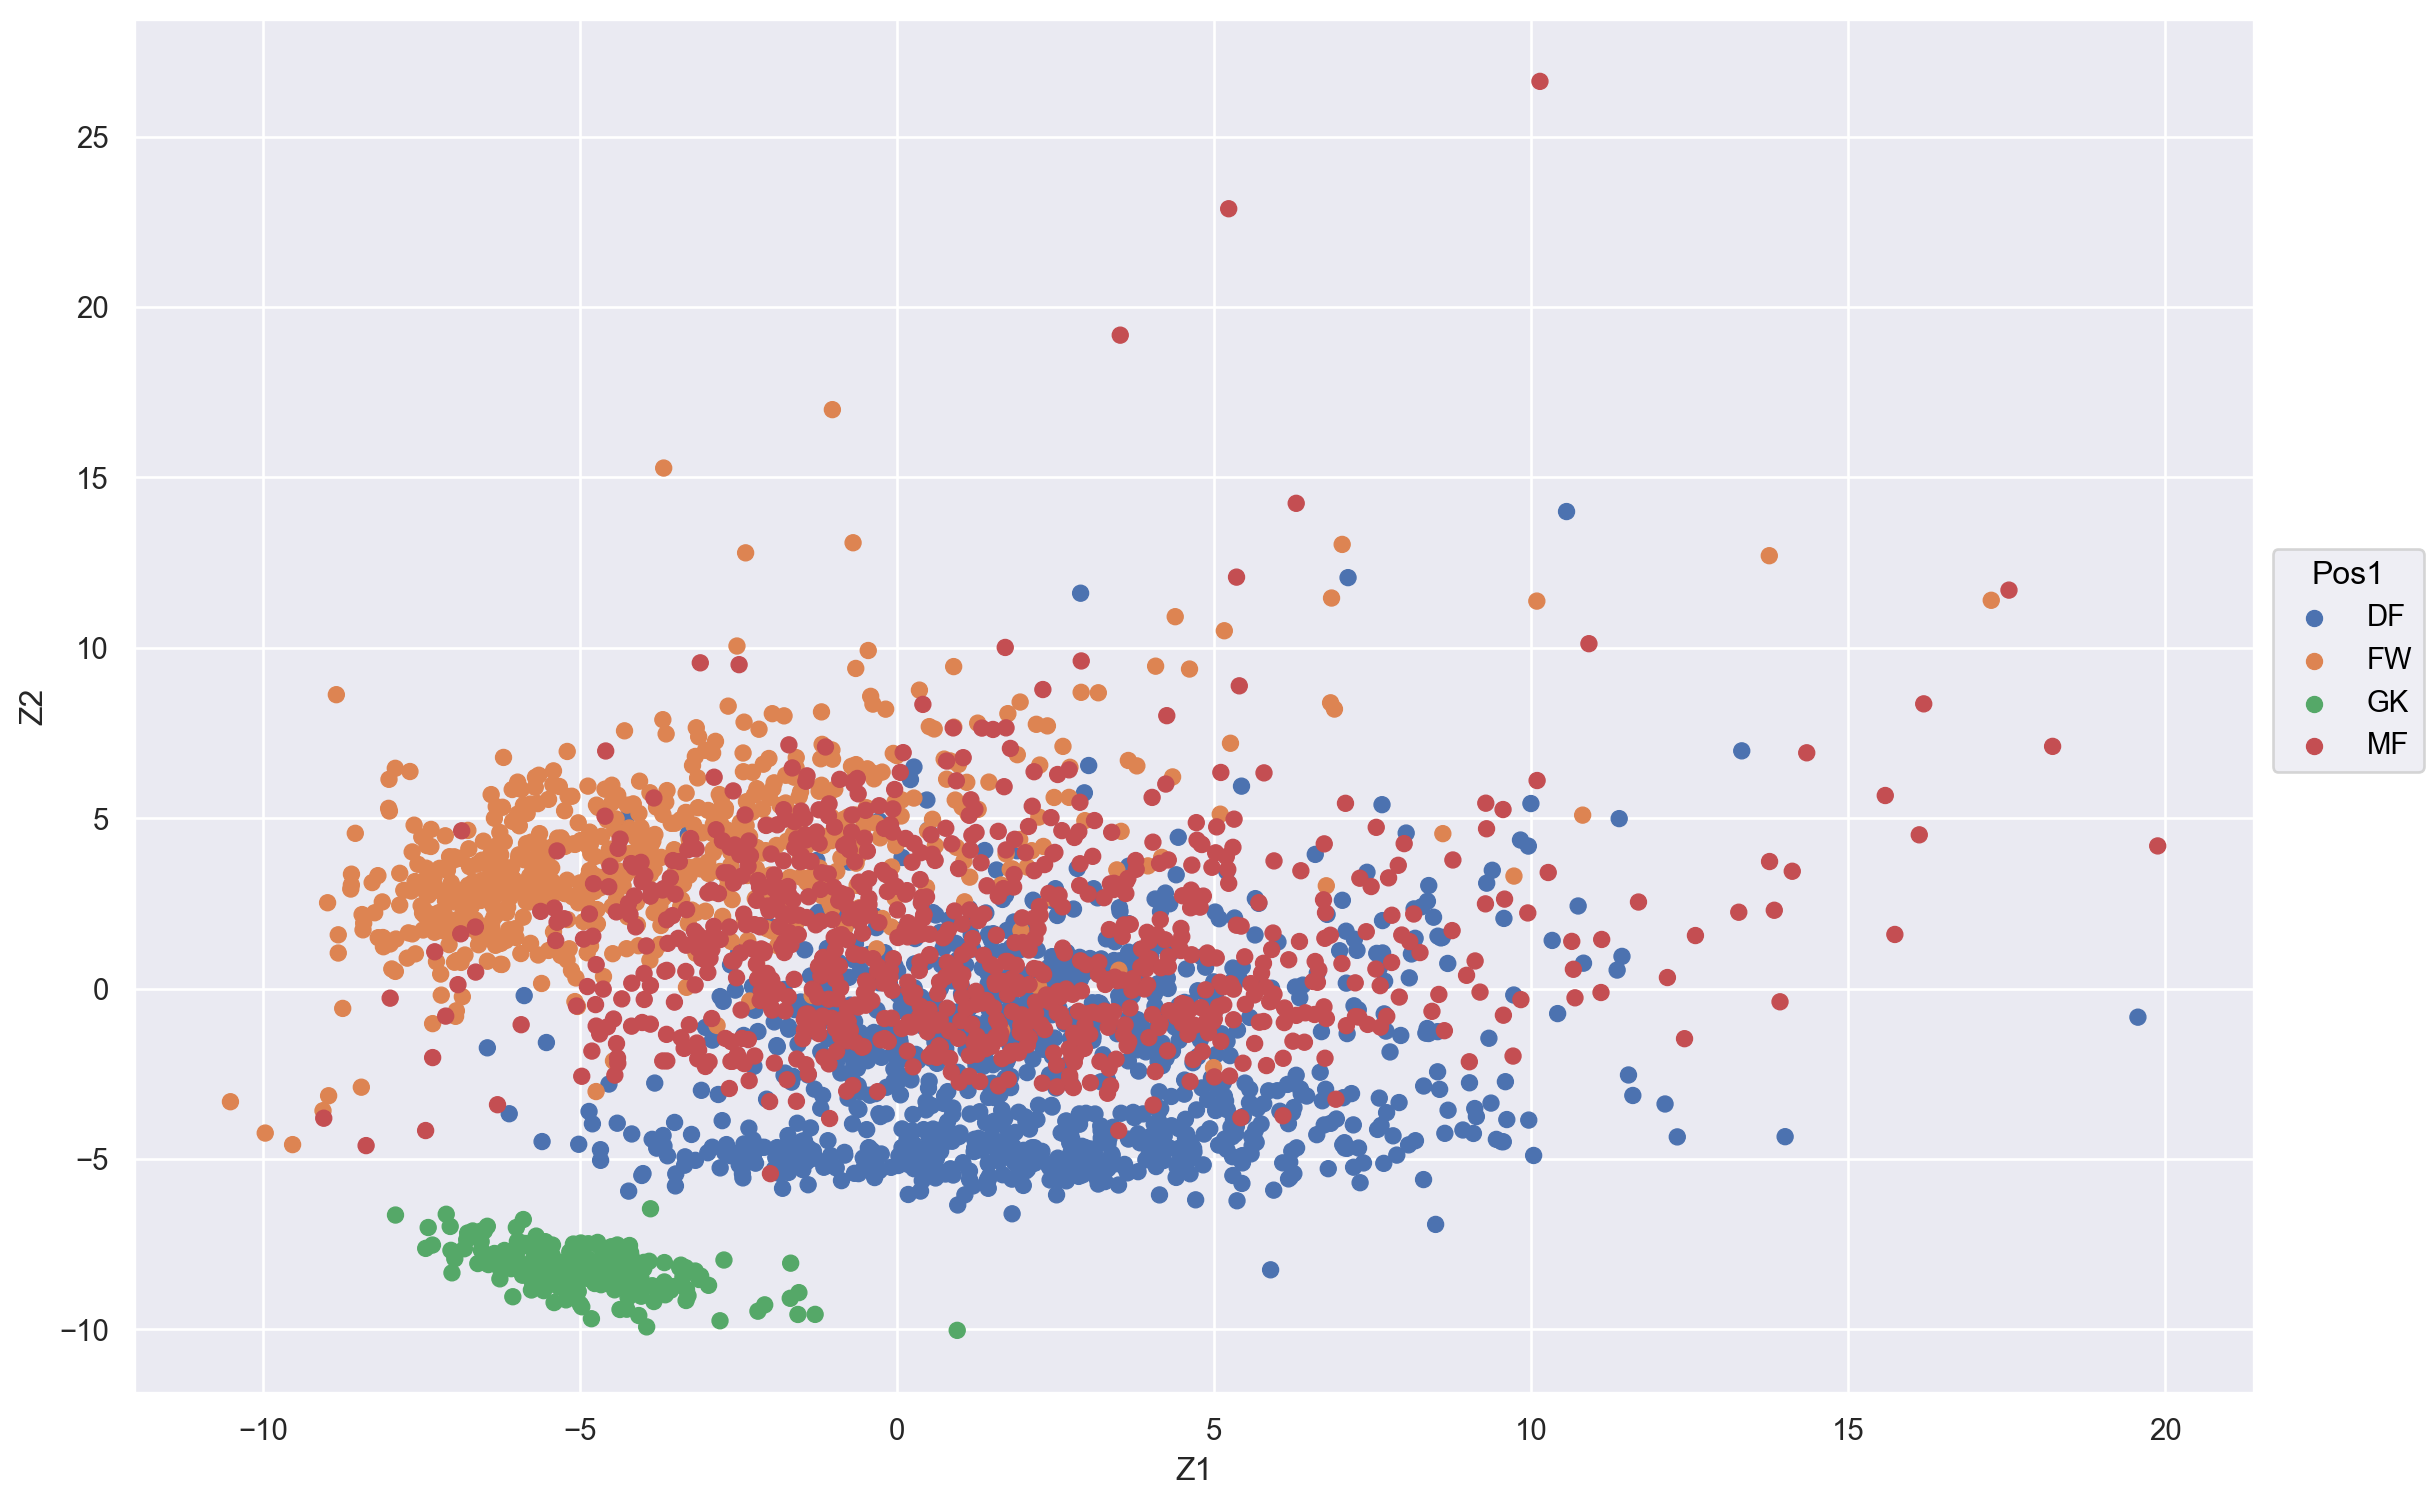

In [26]:
# Graficamos
(
    so.Plot(data = pCompPos, x = "Z1", y = "Z2", color = "Pos1")
    .add(so.Dot())
    .layout(size=(12,8))
)

In [28]:
pCompPos.Pos1.value_counts()

Pos1
DF    1001
MF     860
FW     674
GK     203
Name: count, dtype: int64

# Clusters

C:\Users\Usuario\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


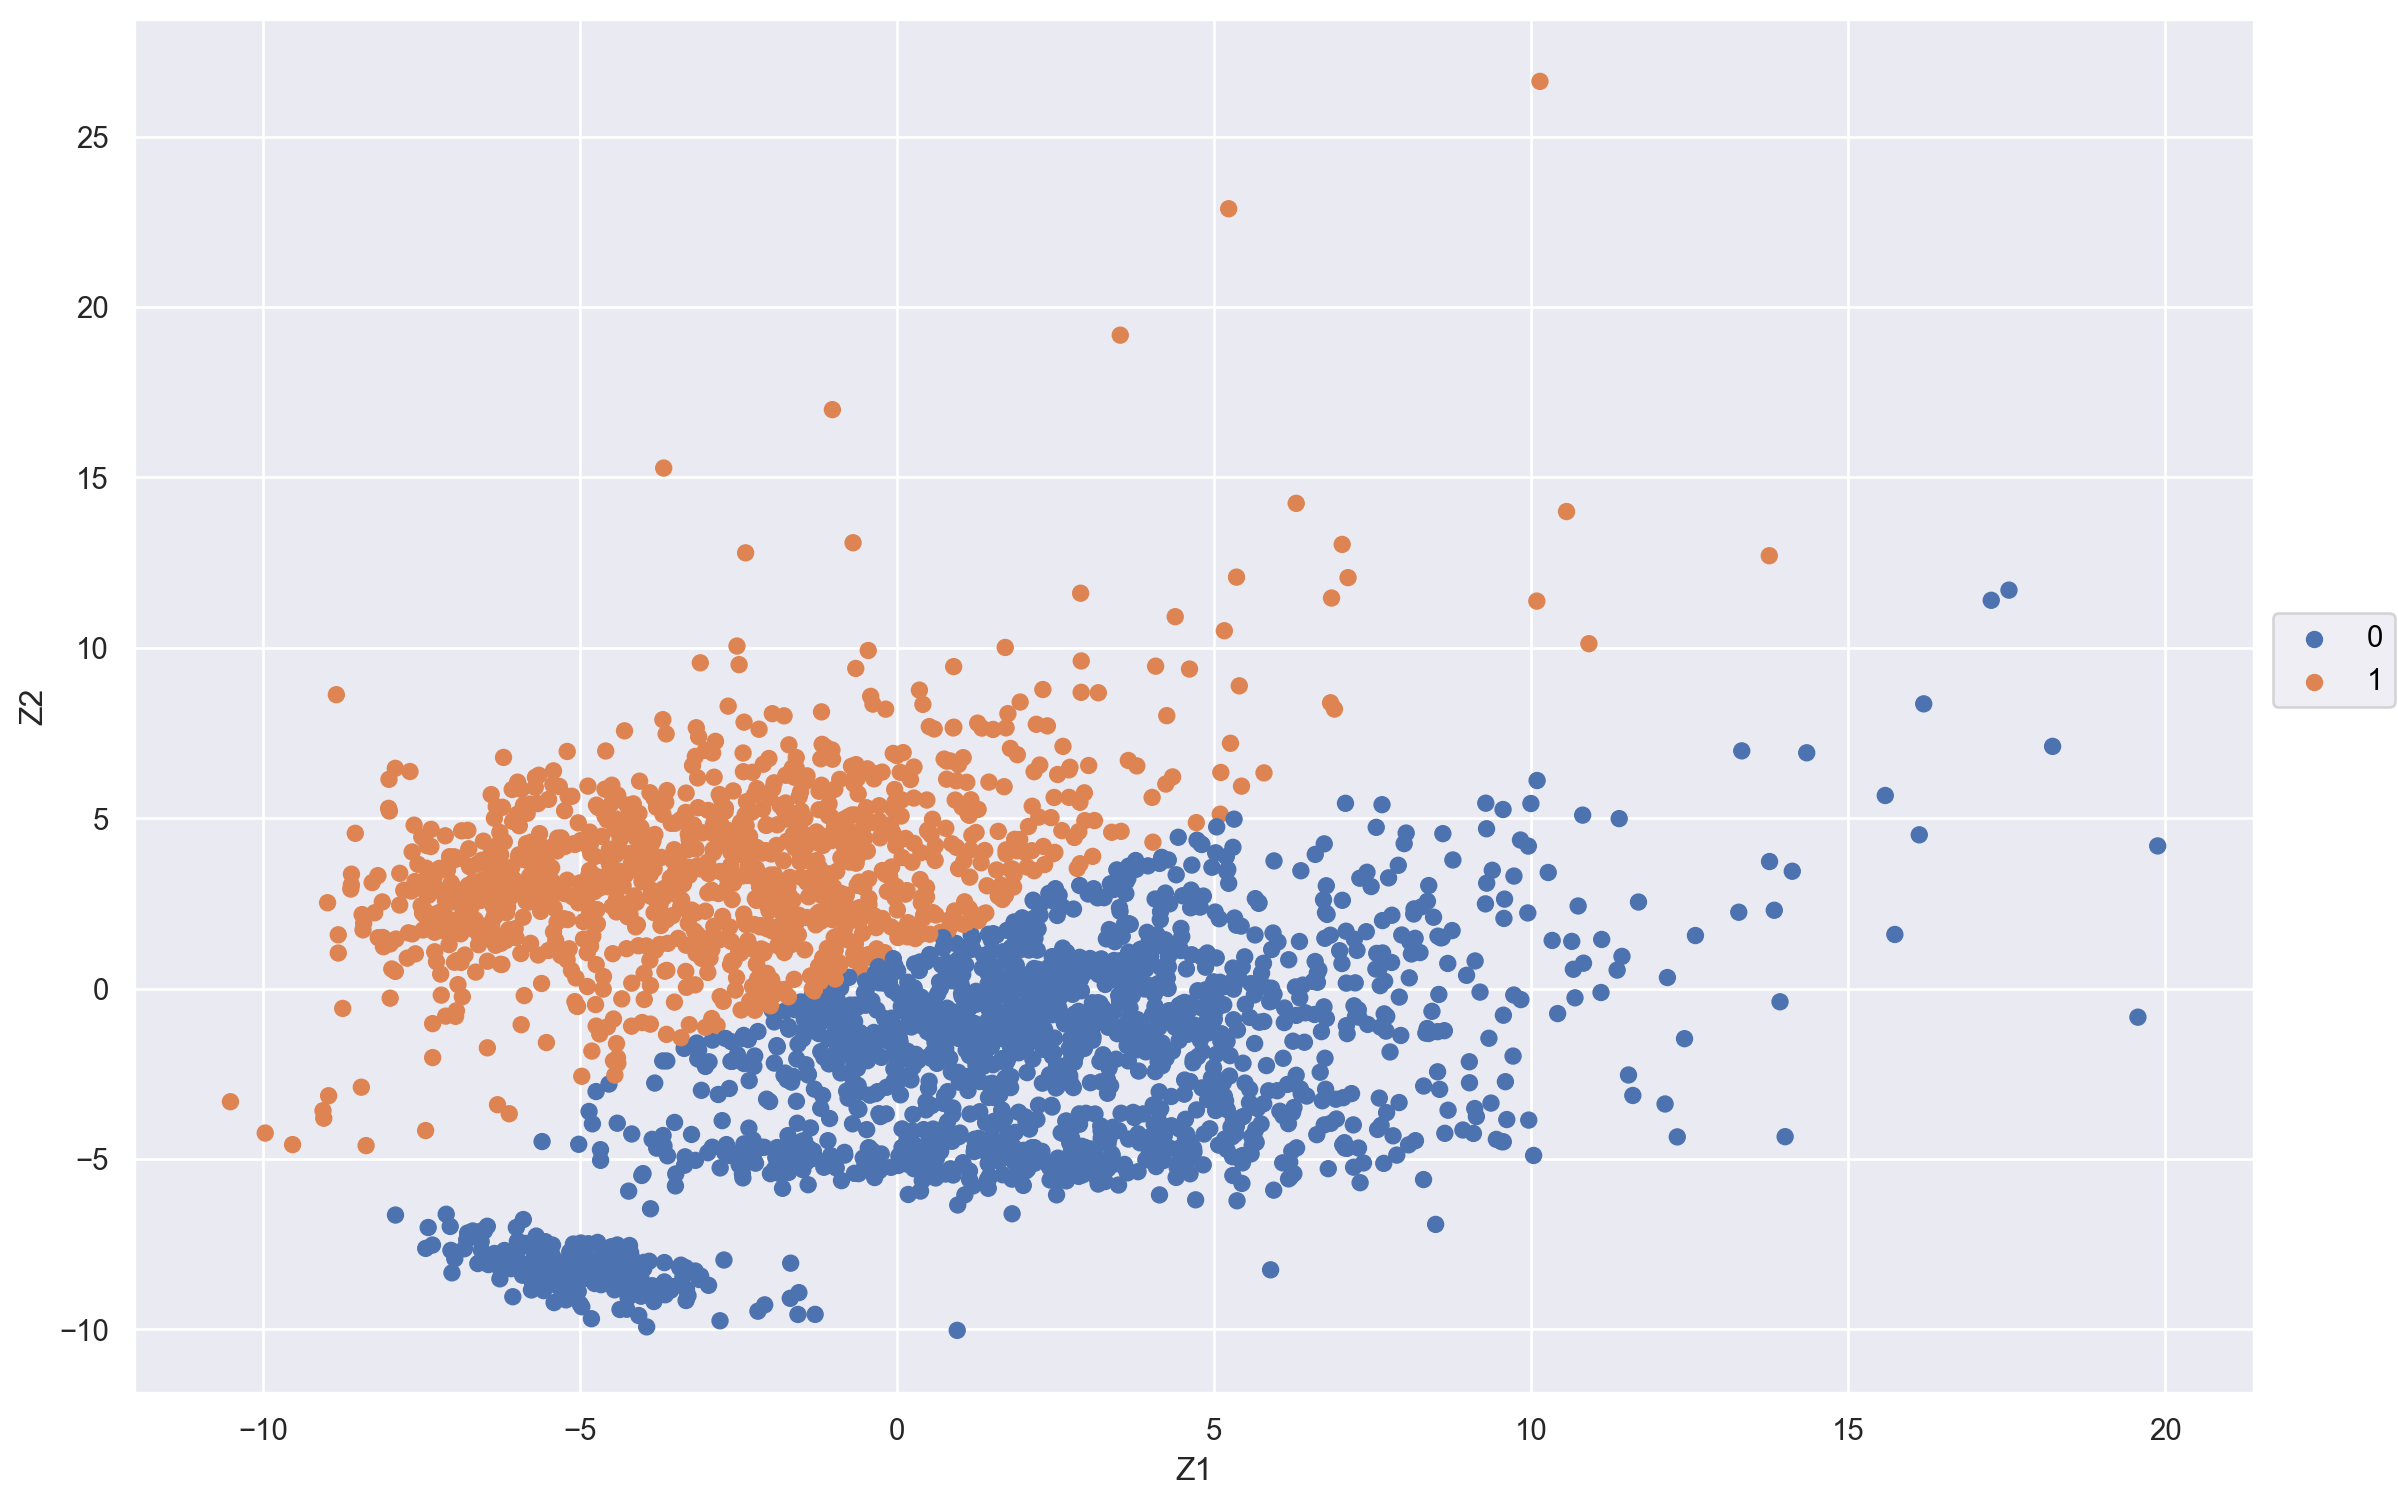

In [34]:
# Con kmeans no funciona bien
kmeans = KMeans(n_clusters=2)
# Asignamos cada observación a un cluster
cluster = kmeans.fit_predict(pComp)
# Graficamos
(
    so.Plot(data = pComp, x = "Z1", y = "Z2", color = cluster.astype(str))
    .add(so.Dot())
    #.add(so.Text())
    .layout(size=(12,8))
)

In [54]:
# Db scan
clustering = DBSCAN(eps=1.5, min_samples=20)
etiqueta = clustering.fit_predict(pComp)
etiqueta

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

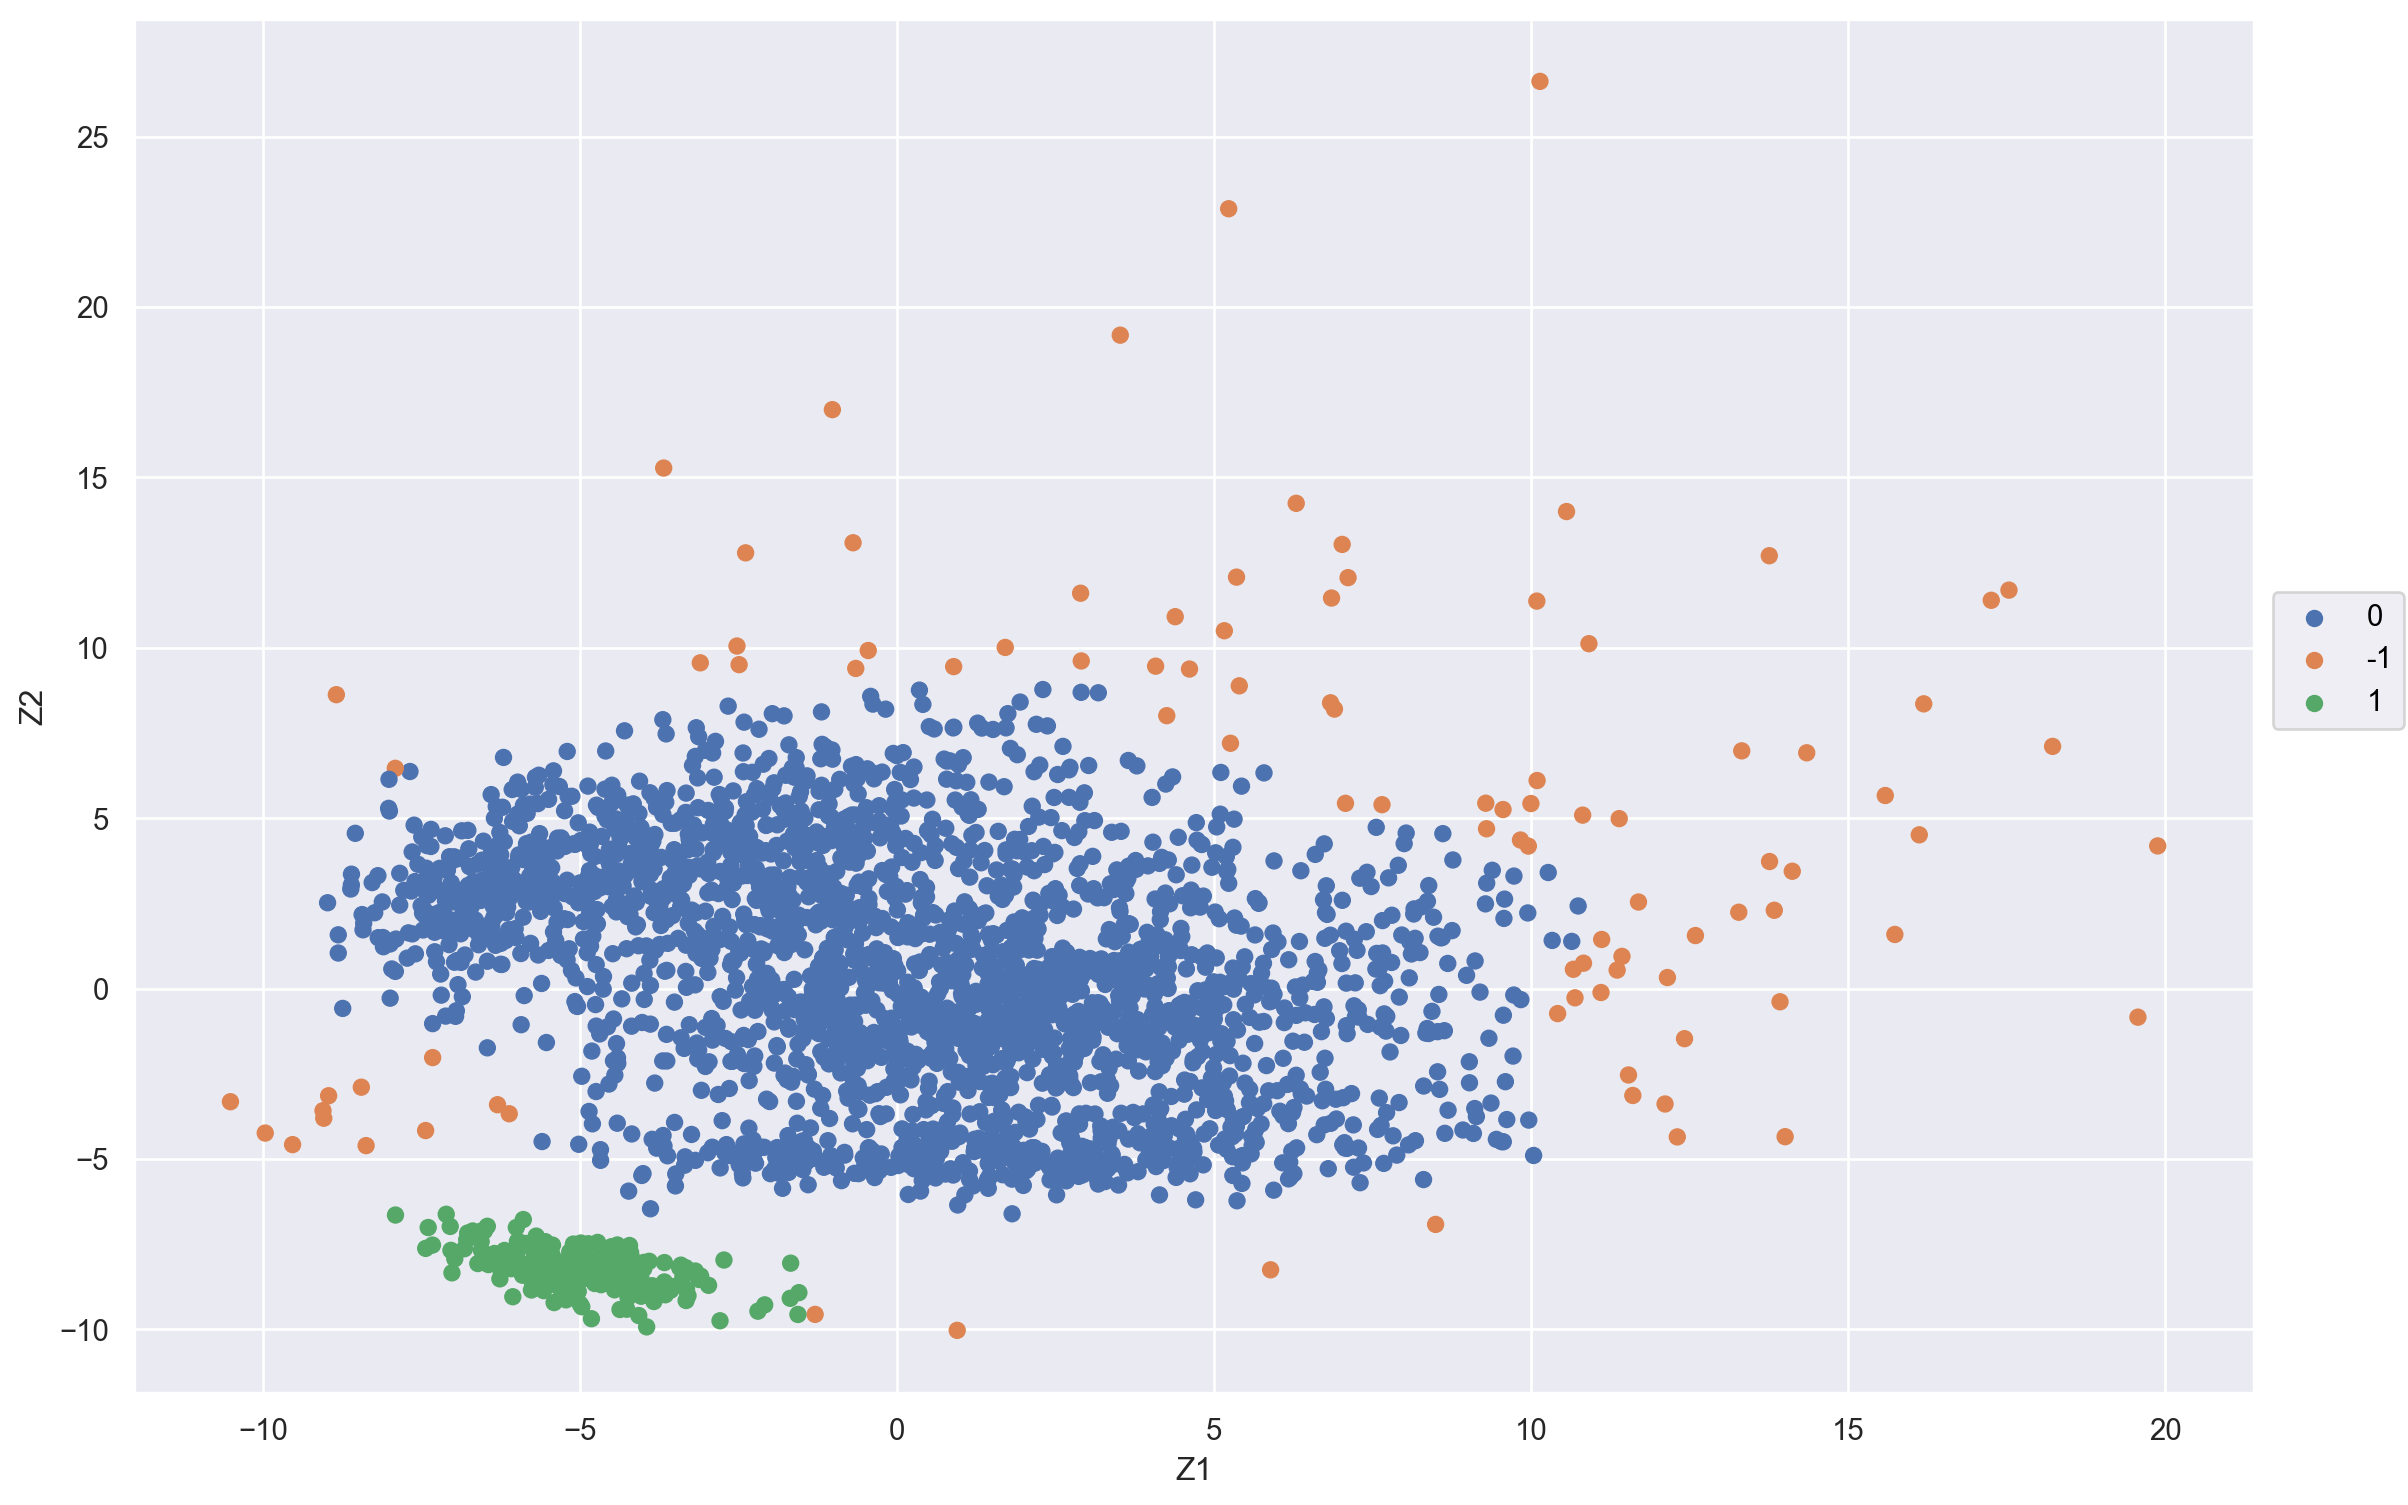

In [55]:
# Graficamos
(
    so.Plot(data = pComp, x = "Z1", y = "Z2", color = etiqueta.astype("str"))
    .add(so.Dot())
    #.add(so.Text())
    .layout(size=(12,8))
)

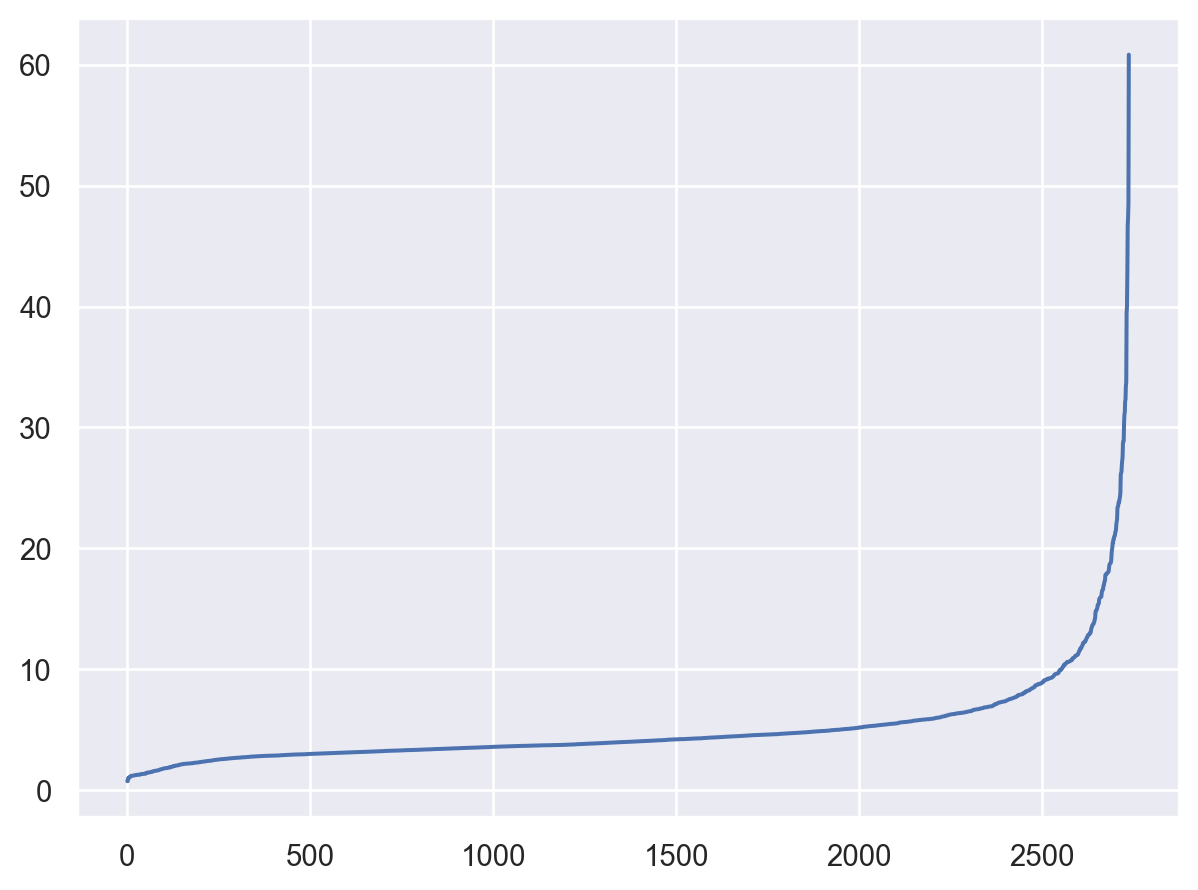

In [37]:
from sklearn.neighbors import NearestNeighbors

dataset = X_star_p
neighbors = NearestNeighbors(n_neighbors=2)  # Esta función nos devuelve los más cercanos incluyendo a si mismo, por eso tomamos 2.
neighbors_fit = neighbors.fit(dataset)

# Ordenamos de menor a mayor las distancias y graficamos
distances, indices = neighbors_fit.kneighbors(dataset)
distances = distances[:,1]
distances = np.sort(distances, axis=0)

so.Plot(x = np.arange(len(distances)), y = distances).add(so.Line())

# Clasificación

In [57]:
# Utilizamos estos paquetes
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [60]:
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import LeaveOneOut    

In [ ]:
# Probamos primero usando solo las componentes principales
error = []

loo = LeaveOneOut()

X = pComp
y = pCompPos["Pos1"]

for i in range(1, 5):  

    classifier = KNeighborsClassifier(n_neighbors=i)  
    y_pred = cross_val_predict(classifier, X, y, cv=loo)
    error.append(np.mean(y_pred != y))

In [61]:
error

[0.3327246165084003,
 0.3177501826150475,
 0.2903579254930606,
 0.2881665449233017]

In [63]:
# Repetimos usando todos los datos
error = []

loo = LeaveOneOut()

X = X_star_p
y = pCompPos["Pos1"]

for i in range(1, 5):  

    classifier = KNeighborsClassifier(n_neighbors=i)  
    y_pred = cross_val_predict(classifier, X, y, cv=loo)
    error.append(np.mean(y_pred != y))

In [65]:
error

[0.133308984660336,
 0.1329437545653762,
 0.12162162162162163,
 0.12016070124178233]

Se obtienen menores errores de clasificación utilizando todas las variables.

In [119]:
#open data
data=pd.read_csv('../Datos/football/transfermarkt_fbref_201920.csv', delimiter=';').dropna().reset_index(drop=True)
data

,Column1,player,nationality,position,squad,age,birth_year,value,height,position2,...,Pts/G,xG,xGA,xGDiff,xGDiff/90,Attendance,CL,WinCL,CLBestScorer,Season
0,21,Martin Aguirregabiria,es ESP,DF,Alavés,23,1996,4000000,178,Defender - Right-Back,...,1.03,37.0,53.2,-16.2,-0.43,"12,177",0,0,0.0,201920#
1,390,Oliver Burke,sco SCO,"MF,FW",Alavés,22,1997,4000000,188,Forward - Right Winger,...,1.03,37.0,53.2,-16.2,-0.43,"12,177",0,0,0.0,201920#
2,430,Ví­ctor Camarasa,es ESP,MF,Alavés,25,1994,4000000,183,Midfielder - Central Midfield,...,1.03,37.0,53.2,-16.2,-0.43,"12,177",0,0,0.0,201920#
3,737,Rubén Duarte,es ESP,DF,Alavés,23,1995,4000000,172,Defender - Left-Back,...,1.03,37.0,53.2,-16.2,-0.43,"12,177",0,0,0.0,201920#
4,770,Rodrigo Ely,br BRA,DF,Alavés,25,1993,1000000,188,Defender - Centre-Back,...,1.03,37.0,53.2,-16.2,-0.43,"12,177",0,0,0.0,201920#
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2212,288,Ryan Bertrand,eng ENG,DF,Southampton,29,1989,10000000,179,Defender - Left-Back,...,1.37,53.9,53.1,0.9,0.02,23428,0,0,0.0,201920#
2213,339,Sofiane Boufal,ma MAR,"MF,FW",Southampton,25,1993,8000000,175,Forward - Left Winger,...,1.37,53.9,53.1,0.9,0.02,23428,0,0,0.0,201920#
2214,619,Kevin Danso,at AUT,DF,Southampton,20,1998,6000000,190,Defender - Centre-Back,...,1.37,53.9,53.1,0.9,0.02,23428,0,0,0.0,201920#
2215,701,Moussa Djenepo,ml MLI,"MF,DF",Southampton,21,1998,11000000,177,Forward - Left Winger,...,1.37,53.9,53.1,0.9,0.02,23428,0,0,0.0,201920#


In [120]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(data.dtypes)

Column1                                     int64
player                                     object
nationality                                object
position                                   object
squad                                      object
age                                         int64
birth_year                                  int64
value                                       int64
height                                      int64
position2                                  object
foot                                       object
league                                     object
games                                       int64
games_starts                                int64
minutes                                     int64
goals                                       int64
assists                                     int64
pens_made                                   int64
pens_att                                    int64
cards_yellow                                int64


In [149]:
data_numeric = data.iloc[:, 15:].drop(["Attendance", "Season"], axis = 1)
data_numeric["age"] = data["age"]

In [150]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(data_numeric.dtypes)

goals                                       int64
assists                                     int64
pens_made                                   int64
pens_att                                    int64
cards_yellow                                int64
cards_red                                   int64
goals_per90                               float64
assists_per90                             float64
goals_assists_per90                       float64
goals_pens_per90                          float64
goals_assists_pens_per90                  float64
xg                                        float64
npxg                                      float64
xa                                        float64
xg_per90                                  float64
xa_per90                                  float64
xg_xa_per90                               float64
npxg_per90                                float64
npxg_xa_per90                             float64
minutes_90s                               float64


In [151]:
data_numeric

,goals,assists,pens_made,pens_att,cards_yellow,cards_red,goals_per90,assists_per90,goals_assists_per90,goals_pens_per90,...,Pts,Pts/G,xG,xGA,xGDiff,xGDiff/90,CL,WinCL,CLBestScorer,age
0,1,1,0,0,5,1,0.04,0.04,0.09,0.04,...,39,1.03,37.0,53.2,-16.2,-0.43,0,0,0.0,23
1,1,2,0,0,2,0,0.06,0.13,0.19,0.06,...,39,1.03,37.0,53.2,-16.2,-0.43,0,0,0.0,22
2,0,1,0,0,1,0,0.00,0.07,0.07,0.00,...,39,1.03,37.0,53.2,-16.2,-0.43,0,0,0.0,25
3,0,1,0,0,11,0,0.00,0.03,0.03,0.00,...,39,1.03,37.0,53.2,-16.2,-0.43,0,0,0.0,23
4,2,0,0,0,9,1,0.08,0.00,0.08,0.08,...,39,1.03,37.0,53.2,-16.2,-0.43,0,0,0.0,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2212,1,1,0,0,3,1,0.03,0.03,0.07,0.03,...,52,1.37,53.9,53.1,0.9,0.02,0,0,0.0,29
2213,0,2,0,0,2,0,0.00,0.24,0.24,0.00,...,52,1.37,53.9,53.1,0.9,0.02,0,0,0.0,25
2214,0,1,0,0,2,1,0.00,0.32,0.32,0.00,...,52,1.37,53.9,53.1,0.9,0.02,0,0,0.0,20
2215,2,2,0,0,4,1,0.19,0.19,0.39,0.19,...,52,1.37,53.9,53.1,0.9,0.02,0,0,0.0,21


In [152]:
# creating and passing series to new column
data[data["player"].str.find("Messi") != -1]

,Column1,player,nationality,position,squad,age,birth_year,value,height,position2,...,Pts/G,xG,xGA,xGDiff,xGDiff/90,Attendance,CL,WinCL,CLBestScorer,Season
256,1649,Lionel Messi,ar ARG,"FW,MF",Barcelona,32,1987,112000000,170,Forward - Right Winger,...,2.16,66.4,36.0,30.4,0.8,54223,1,0,0.0,201920#


In [153]:
from sklearn.neighbors import NearestNeighbors

In [154]:
nbrs = NearestNeighbors(n_neighbors=10).fit(data_numeric)
distances, indices = nbrs.kneighbors(data_numeric.loc[[256]])

In [155]:
indices

array([[ 256,  143, 1534, 1685,  681, 1230, 1207,  945,  112,  277]],
      dtype=int64)

In [156]:
data.iloc[indices.flatten()]

,Column1,player,nationality,position,squad,age,birth_year,value,height,position2,...,Pts/G,xG,xGA,xGDiff,xGDiff/90,Attendance,CL,WinCL,CLBestScorer,Season
256,1649,Lionel Messi,ar ARG,"FW,MF",Barcelona,32,1987,112000000,170,Forward - Right Winger,...,2.16,66.4,36.0,30.4,0.80,54223,1,0,0.0,201920#
143,977,Papu Gómez,ar ARG,"MF,FW",Atalanta,31,1988,15000000,165,Forward - Second Striker,...,2.05,81.9,41.4,40.4,1.06,11167,1,0,0.0,201920#
1534,1086,Theo Hernández,fr FRA,DF,Milan,21,1997,32000000,184,Defender - Left-Back,...,1.74,60.1,47.6,12.5,0.33,34078,0,0,0.0,201920#
1685,2711,Piotr Zieliński,pl POL,MF,Napoli,25,1994,32000000,180,Midfielder - Central Midfield,...,1.63,62.5,39.3,23.2,0.61,21622,0,0,0.0,201920#
681,1050,Achraf Hakimi,ma MAR,"DF,FW",Dortmund,20,1998,54000000,181,Midfielder - Right Midfield,...,2.03,59.2,39.4,19.8,0.58,57297,1,0,0.0,201920#
1230,433,José Campaña,es ESP,MF,Levante,26,1993,12000000,179,Midfielder - Central Midfield,...,1.29,41.9,60.7,-18.8,-0.50,13196,0,0,0.0,201920#
1207,506,Ben Chilwell,eng ENG,DF,Leicester City,22,1996,40000000,178,Defender - Left-Back,...,1.63,61.6,44.5,17.1,0.45,25312,0,0,0.0,201920#
945,82,Sofyan Amrabat,ma MAR,MF,Hellas Verona,22,1996,14000000,185,Midfielder - Central Midfield,...,1.29,49.1,52.6,-3.5,-0.09,11248,0,0,0.0,201920#
112,1002,Jack Grealish,eng ENG,"FW,MF",Aston Villa,23,1995,30000000,180,Midfielder - Attacking Midfield,...,0.92,40.1,65.9,-25.8,-0.68,28505,0,0,0.0,201920#
277,625,Alphonso Davies,ca CAN,DF,Bayern Munich,18,2000,45000000,183,Defender - Left-Back,...,2.41,82.3,34.3,48.0,1.41,57353,1,0,0.0,201920#


In [157]:
y = data["value"]

In [158]:
from sklearn import linear_model    # Herramientas de modelos lineales
from sklearn.metrics import mean_squared_error, r2_score    # Medidas de desempeño
from sklearn.preprocessing import PolynomialFeatures    # Herramientas de polinomios

In [159]:
modelo = linear_model.LinearRegression()    # Inicializamos un modelo de Regresion Lineal
modelo.fit(data_numeric, y)   # Realizamos el ajuste


LinearRegression()

In [160]:
y_pred = modelo.predict(data_numeric)
r2_score(y, y_pred)

0.6964175674442667

In [161]:
y

0        4000000
1        4000000
2        4000000
3        4000000
4        1000000
          ...   
2212    10000000
2213     8000000
2214     6000000
2215    11000000
2216     6000000
Name: value, Length: 2217, dtype: int64

In [162]:
y_pred

array([ 1706010.76600152,  9916660.83237036,  6644814.91182828, ...,
        3962241.96641999, 11324007.01479725, 10612354.93601464])

In [163]:
y[256]  # Valor de mercado de Messi

112000000

In [164]:
y_pred[256]  # Predicción

113492811.69470647

In [165]:
np.argmax(y - y_pred)   # Jugador más sobravalorado según el modelo...

1843

In [166]:
data.loc[1843]

Column1                  1602
player          Kylian Mbappé
nationality            fr FRA
position                   FW
squad               Paris S-G
                    ...      
Attendance              47517
CL                          1
WinCL                       0
CLBestScorer              0.0
Season                201920#
Name: 1843, Length: 400, dtype: object

In [167]:
np.max(y - y_pred)   # Jugador más sobravalorado según el modelo...

85181629.68317756

In [168]:
y[1843]

180000000

In [169]:
y_pred[1843]

94818370.31682244

In [170]:
nbrs = NearestNeighbors(n_neighbors=10).fit(data_numeric)
distances, indices = nbrs.kneighbors(data_numeric.loc[[1843]])

In [171]:
data.iloc[indices.flatten()]

,Column1,player,nationality,position,squad,age,birth_year,value,height,position2,...,Pts/G,xG,xGA,xGDiff,xGDiff/90,Attendance,CL,WinCL,CLBestScorer,Season
1843,1602,Kylian Mbappé,fr FRA,FW,Paris S-G,20,1998,180000000,178,Forward - Left Winger,...,2.52,70.9,22.7,48.2,1.78,47517,1,0,0.0,201920#
1239,1473,José Luis Morales,es ESP,"FW,MF",Levante,32,1987,6000000,180,Forward - Centre-Forward,...,1.29,41.9,60.7,-18.8,-0.50,13196,0,0,0.0,201920#
1385,1222,Lago Junior,ci CIV,"MF,FW",Mallorca,28,1990,2500000,180,Forward - Left Winger,...,0.87,39.2,60.6,-21.4,-0.56,10877,0,0,0.0,201920#
1205,199,Harvey Barnes,eng ENG,"MF,FW",Leicester City,21,1997,17000000,182,Midfielder - Left Midfield,...,1.63,61.6,44.5,17.1,0.45,25312,0,0,0.0,201920#
1656,2325,Moses Simon,ng NGA,"FW,MF",Nantes,24,1995,6000000,168,Forward - Left Winger,...,1.32,27.8,33.5,-5.7,-0.20,24635,0,0,0.0,201920#
2046,336,Denis Bouanga,ga GAB,"FW,DF",Saint-Étienne,24,1994,8000000,180,Forward - Left Winger,...,1.07,28.8,35.3,-6.6,-0.23,"23,205",0,0,0.0,201920#
1256,238,Karim Bellarabi,de GER,"FW,DF",Leverkusen,29,1990,12000000,184,Forward - Right Winger,...,1.85,56.6,45.1,11.5,0.34,21236,0,0,0.0,201920#
242,2577,Ruben Vargas,ch SUI,"FW,MF",Augsburg,20,1998,9000000,174,Forward - Left Winger,...,1.06,42.1,54.9,-12.9,-0.38,20265,0,0,0.0,201920#
1440,1559,Anthony Martial,fr FRA,FW,Manchester Utd,23,1995,48000000,181,Forward - Centre-Forward,...,1.74,59.4,37.4,22.0,0.58,57415,1,0,0.0,201920#
930,1491,Darwin Machí­s,ve VEN,"FW,MF",Granada,26,1993,3000000,171,Forward - Left Winger,...,1.47,41.0,41.1,-0.1,0.00,11174,0,0,0.0,201920#


In [172]:
y_pred[indices.flatten()] - y[indices.flatten()]

1843   -8.518163e+07
1239    8.891486e+06
1385   -1.991589e+06
1205    9.186415e+06
1656    1.287104e+07
2046    5.691722e+06
1256    5.998820e+06
242     9.006711e+06
1440    4.207161e+06
930     8.416421e+06
Name: value, dtype: float64